<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/voluntarios/Voluntario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Formación de las galaxias a partir de sistemas solares**

**Resumen**

Este ejercicio consiste en simular la evolución de una galaxia, compuesta por un agujero negro supermasivo central, y N sistemas solares en órbita. Se considera la atracción central del agujero negro y las interacciones entre sistemas solares. Por eficiencia, la interacción entre sistemas solares solo se calculará para sistemas cercanos entre sí. La dinámica esta regida por la segunda Ley de Newton, teniendo en cuenta las posibles colisiones elásticas, en las que se conserva la energía cinética y el momento lineal. Se implementa el algoritmo de Verlet en Velocidad. La elección de este método se basa en su eficiencia computacional, pero sobretodo en que garantiza la conservación de la energía y momento angular. Se analizará la evolución del momento angular del sistema, la densidad de Masa Radial, y el Flujo de Masa.

**Fundamento teórico**

*1. Dinámica del sistema de N Cuerpos*

El modelo describe una galaxia, compuesta por un agujero negro masivo centrall, y N pequeños cuerpos (sistemas solares), orbitando alrededor de éste con diferentes energías y excentricidades. La evolución de cada cuerpo $i$ viene dada por la segunda ley de Newton:
$$m_{i}\frac{d^{2}r_{i}}{dt^{2}}=-Gm_{i}\frac{M_{BH}r_i}{|r_i|^3} - Gm_{i}\sum_{j\ne i}\frac{m_{j}(r_{i}-r_{j})}{|r_{i}-r_{j}|^{3}}$$

*2. Algoritmo de Verlet en Velocidad*

Para resolver numéricamente estas ecuaciones diferenciales, empleamos el algoritmo de Verlet en velocidad, basado en el desarrollo de Taylor de la posición y la velocidad.

$$r(t+h)=r(t)+hv(t)+\frac{h^{2}}{2}a(t)$$$$v(t+h)=v(t)+\frac{h}{2}[a(t)+a(t+h)]$$

Este algoritmo conserva en media la energía cinética y el momento angular del sistema, crítico para asegurar que la dinámica observada sea físicamente real.

**Estructura y Funcionamiento del Código**


Primero, configuramos el modelo. Añadimos un tiempo de relajación. Esto se debe a que los sistemas solares necesitan un tiempo para alcanzar el estado estacionario. Durante este periodo de relajación, el sistema es inestable y los observables oscilan bruscamente.


In [ ]:
import numpy as np # Para el cálculo científico
import matplotlib.pyplot as plt # Para visualización

N_SISTEMAS = 100    #Cantidad de sistemas solares simulados
G = 1.0             # Constante gravitacional en unidades naturales
M_BH = 5000.0        # Masa del agujero negro central
M_SYS = 1.0          # Masa de cada sistema solar
R_SISTEMA = 0.3     # Radio de cada sistema solar
DT = 0.01               # Paso de tiempo
PASOS_RELAJACION = 5000  # Tiempo para alcanzar el estado estacionario
PASOS_MEDICION = 5000    # Mediciones en estado estacionario
R_MAX = 25.0           # Radio máximo de la simulación
R_ABS = 1          # Radio de absorción del agujero negro


Damos una velocidad inicial a los sistemas solares para que estos no caigan directamente en el agujero negro. Usamos la formula de la velocidad obtenida al igualar la fuerza centrípeta y la gravitatoria: $v = \sqrt{GM/r}$. Es decir, los sistemas tendrán una órbita circular, al menos al principio, para que no colapse directamente. La excentricidad se da de forma natural con el tiempo, debido a la interacción gravitatoria.
Las posiciones iniciales de los sistemas también se dan de forma aleatoria inicialmente.

In [ ]:
pos = np.random.uniform(-R_MAX/2, R_MAX/2, (N_SISTEMAS, 2))
vel = np.zeros_like(pos)

for i in range(N_SISTEMAS):
    r_mag = np.linalg.norm(pos[i])
    v_mag = np.sqrt(G * M_BH / r_mag)
    vel[i] = np.array([-pos[i, 1], pos[i, 0]]) / r_mag * v_mag



Aquí, [-y, x] es un vector perpendicular, que le da velocidad tangencial al cuerpo para que sea capaz de orbitar. Al dividir por $r_{mag}$ unitarizamos el vector, y al multiplicar por $v_{mag}$ le damos la velocidad necesaria para mantener una órbita circular.

Calculamos la aceleración con la ley de Newton en cada instante con la siguiente función:


In [ ]:
def calcular_aceleracion(p):
    acc = np.zeros_like(p)
    # Gravedad central (Agujero Negro)
    dist_sq = np.sum(p**2, axis=1).reshape(-1, 1)
    dist = np.sqrt(dist_sq)
    acc -= G * M_BH * p / (dist**3)

    # Interacción entre sistemas cercanos: Solo calculamos la gravedad
    # entre 2 sistemas si están a una distancia menor a 3 unidades.
    for i in range(len(p)):
        for j in range(i + 1, len(p)):
            diff = p[j] - p[i]
            d_ij = np.linalg.norm(diff)
            if d_ij < 3.0: # Umbral de cercanía
                f = G * M_SYS * diff / (d_ij**3)
                acc[i] += f
                acc[j] -= f
    return acc

Ahora implementamos el algoritmo de Verlet:


In [ ]:
# --- Contenedores para el análisis ---
historial_inercia = []
radios_estacionarios = []
absorciones = 0

# --- Bucle de Evolución (Verlet en Velocidad) ---
total_pasos = PASOS_RELAJACION + PASOS_MEDICION

for paso in range(total_pasos):
    a_t = calcular_aceleracion(pos)

    # Actualización con algoritmo Verlet
    pos_nueva = pos + DT * vel + 0.5 * (DT**2) * a_t
    w = vel + 0.5 * DT * a_t
    a_t_h = calcular_aceleracion(pos_nueva)
    vel_nueva = w + 0.5 * DT * a_t_h

    pos, vel = pos_nueva, vel_nueva


    # Aquí vemos si hay colisiones entre sistemas solares. Si dos sistemas están a menos de 2 unidades de distancia,
    # consideramos que colisionan y rebotan, intercambiando sus velocidades.
    for i in range(N_SISTEMAS):
        for j in range(i + 1, N_SISTEMAS):
            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)
            if dist < (2 * R_SISTEMA):
                # Rebotan: intercambian velocidades
                vel[i], vel[j] = vel[j].copy(), vel[i].copy()

    # Gestión de absorción y regeneración: la masa que entra debe ser igual a
    # la que sale para mantener el número constante de sistemas solares.
    for i in range(N_SISTEMAS):
        r_i = np.linalg.norm(pos[i])
        # Si el sistema solar se acerca demasiado al agujero o se aleja demasiado,
        # lo consideramos absorbido o perdido.
        if r_i < R_ABS or r_i > R_MAX * 1.5:
            if r_i < R_ABS: absorciones += 1
            # Regenerar en la frontera con órbita cerrada
            ang = np.random.uniform(0, 2*np.pi)
            pos[i] = np.array([np.cos(ang), np.sin(ang)]) * R_MAX
            v_orb = np.sqrt(G * M_BH / R_MAX)
            vel[i] = np.array([-np.sin(ang), np.cos(ang)]) * v_orb

    # Análisis post-relajación
    inercia = np.sum(M_SYS * np.sum(pos**2, axis=1))
    historial_inercia.append(inercia)

    if paso > PASOS_RELAJACION:
        radios_estacionarios.extend(np.linalg.norm(pos, axis=1))

A continuación, analizamos los resultados.

1. Flujo medio de masa: cuanto material es absorbido por el agujero engro por unidad de tiempo, en el estado estacionario.

In [ ]:
flujo = (absorciones * M_SYS) / (total_pasos * DT)

2. Densidad radial media: cuántos sistemas solares hay en cada anillo radial y divido por el área de ese anillo para obtener la densidad.

In [ ]:
counts, bins = np.histogram(radios_estacionarios, bins=30, range=(0, R_MAX))
areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
densidad_radial = (counts / (PASOS_MEDICION)) / areas

Para la visualización de los resultados:


In [ ]:
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

 Si el sistema es estable, el valor del momento de inercia no debería crecer ni disminuir sistemáticamente. Si esto ocurre es que el sistema no ha llegado a alcanzar el estado estacionario. En este caso, aumentar el valor de pasos de relajación.
 Si la tasa de 'nacimientos' es mayor que la tasa de 'muertes', la inercia total no va a dejar de subir.

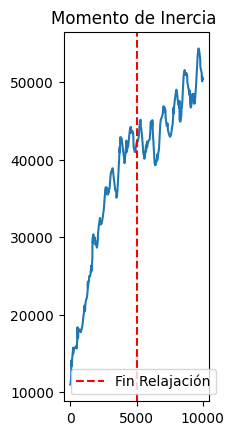

In [ ]:
plt.subplot(1, 3, 1)
plt.plot(historial_inercia)
plt.axvline(PASOS_RELAJACION, color='r', linestyle='--', label='Fin Relajación')
plt.title("Momento de Inercia ")
plt.legend()

Muestra masa por ud. de área. La mayor parte de la masa debería estar concentrada  cerca del agujero (a la izquierda del gráfico) y luego decaer a medida que nos alejamos.
 Si vemos un pico a la derecha, se debe a que cuando un sistema solar es absorbido, se inserta uno nuevo en la frontera con órbita circular, lo que genera una acumulación de sistemas solares en esa región.
 Al 'nacer' con velocidad circular en ese radio, los sistemas tienden a quedarse orbitando cerca de donde nacieron.

Text(0.5, 1.0, 'Densidad de Masa Radial ')

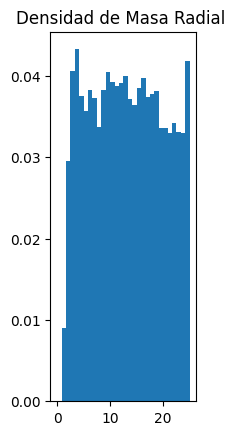

In [ ]:
plt.subplot(1, 3, 2)
plt.bar(bins[:-1], densidad_radial, width=np.diff(bins), align='edge')
plt.title("Densidad de Masa Radial ")

Mapa de posiciones finales de los sistemas solares. Deberíamos ver una concentración de puntos cerca del centro (agujero negro) y luego una distribución más dispersa a medida que nos alejamos.

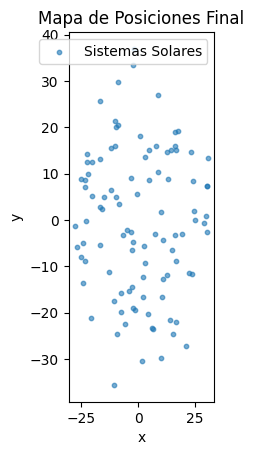

In [ ]:
plt.subplot(1, 3, 3)
plt.scatter(pos[:, 0], pos[:, 1], s=10, alpha=0.6, label='Sistemas Solares')
plt.title("Mapa de Posiciones Final")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

Mostramos el flujo medio como texto en la figura.

In [ ]:
info_texto = f"Flujo Medio de Masa: {flujo:.6f} M_sol/dt"
plt.figtext(0.5, 0.01, info_texto, ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.tight_layout()
plt.show()

print(f"Flujo medio de masa absorbida: {flujo:.4f} M_sol/unidad_tiempo ")

<Figure size 640x480 with 0 Axes>

Flujo medio de masa absorbida: 0.1600 M_sol/unidad_tiempo 
